In [ ]:
from pathlib import Path
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import numpy as np



## Helpers



In [ ]:
N_COLOR_GROUPS = 4


def plane_patch(points, scale=1.15):
    center = points.mean(axis=0)
    centered = points - center
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    basis = vt[:2]
    coords = centered @ basis.T
    lo = coords.min(axis=0) * scale
    hi = coords.max(axis=0) * scale
    corners_2d = np.array([[lo[0], lo[1]], [hi[0], lo[1]], [hi[0], hi[1]], [lo[0], hi[1]]])
    return center + corners_2d @ basis

def pca_project_conditions(dat, n_components=3):
    valid_units = np.all(np.isfinite(dat), axis=0)
    clean_dat = dat[:, valid_units]
    centered = clean_dat - np.mean(clean_dat, axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(centered, full_matrices=False)
    scores = u[:, :n_components] * s[:n_components]
    explained = (s ** 2) / np.sum(s ** 2)
    return scores, explained[:n_components], valid_units


### Here using bin 6, because it seems to work, but should be adapted if using other windows leghts etc

In [10]:
cond_means_pre= np.load("cond_means_pre.npy")
cond_means_post = np.load("cond_means_post.npy")

pre_dat = np.array(cond_means_pre)[:,:,6].T
post_dat = np.array(cond_means_post)[:,:,6].T


In [11]:
pre_scores, pre_explained, pre_valid_units = pca_project_conditions(pre_dat)
print("Pre-cue explained variance:", pre_explained)
print("Pre valid units:", np.sum(pre_valid_units), "/", len(pre_valid_units))

post_scores, post_explained, post_valid_units = pca_project_conditions(post_dat)
print("post-cue explained variance:", post_explained)
print("post valid units:", np.sum(post_valid_units), "/", len(post_valid_units))


Pre-cue explained variance: [0.34319579 0.15817093 0.13783016]
Pre valid units: 272 / 272
post-cue explained variance: [0.35863997 0.20759016 0.1153275 ]
post valid units: 272 / 272


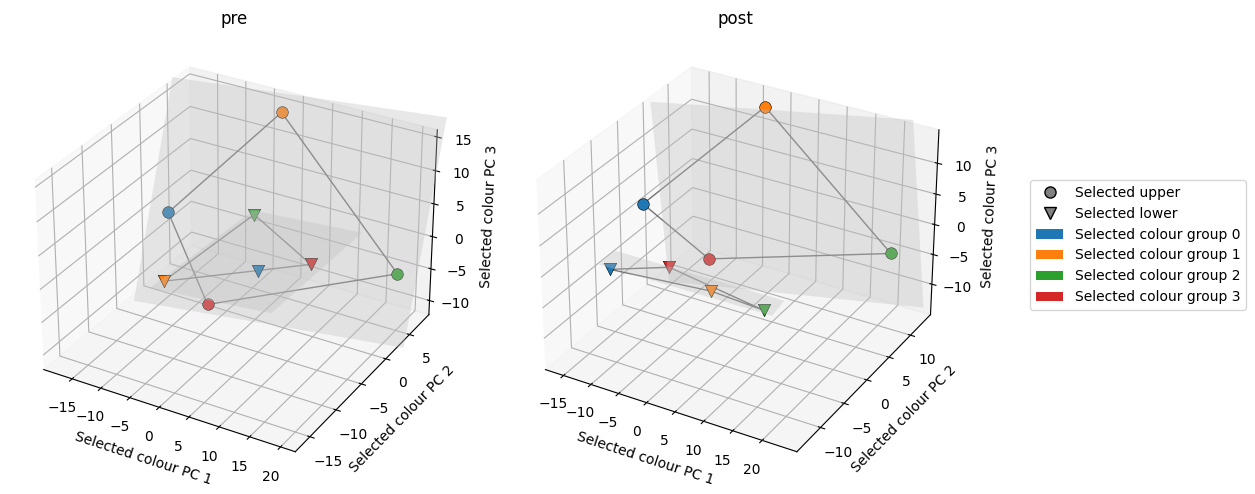

In [13]:
group_colours = plt.cm.tab10(np.arange(N_COLOR_GROUPS))

def plot_panel(ax, scores, title):
    upper = scores[:N_COLOR_GROUPS]
    lower = scores[N_COLOR_GROUPS:]

    ax.add_collection3d(Poly3DCollection([plane_patch(upper)], facecolor="0.75", alpha=0.35, edgecolor="none"))
    ax.add_collection3d(Poly3DCollection([plane_patch(lower)], facecolor="0.75", alpha=0.35, edgecolor="none"))

    for group_id in range(N_COLOR_GROUPS):
        ax.scatter(*upper[group_id], marker="o", s=70, color=group_colours[group_id], edgecolor="black", linewidth=0.4)
        ax.scatter(*lower[group_id], marker="v", s=80, color=group_colours[group_id], edgecolor="black", linewidth=0.4)

    for points in [upper, lower]:
        x=ax1.get_xlim3d()[0]
        y=ax1.get_ylim3d()[0]
        z=ax1.get_zlim3d()[0]

        closed = np.vstack([points, points[0]])
        ax.plot(closed[:, 0], closed[:, 1], closed[:, 2], color="0.45", linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("Selected colour PC 1")
    ax.set_ylabel("Selected colour PC 2")
    ax.set_zlabel("Selected colour PC 3")
    ax.grid(True)


fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

plot_panel(ax1, pre_scores, "pre")
plot_panel(ax2, post_scores, "post")

marker_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="0.5", markeredgecolor="black", label="Selected upper", markersize=8),
    plt.Line2D([0], [0], marker="v", color="w", markerfacecolor="0.5", markeredgecolor="black", label="Selected lower", markersize=9),
]
colour_handles = [Patch(facecolor=group_colours[i], label=f"Selected colour group {i}") for i in range(N_COLOR_GROUPS)]
fig.legend(handles=marker_handles + colour_handles, loc="center right", bbox_to_anchor=(1.08, 0.5))
plt.tight_layout(rect=(0, 0, 0.88, 1))